# AML Detection System — Performance Evaluation

**Project:** Anti-Money Laundering Detection System  
**Author:** Moavia Mahmood  
**Purpose:** Compute classification metrics (precision, recall, F1, ROC/AUC) for the 14-rule AML detection layer against ground-truth labels stamped by the synthetic data generator.

## What this notebook does

1. Pulls the `aml_db.evaluation_dataset` view from Athena into a pandas DataFrame.
2. Computes the **aggregate confusion matrix** and headline metrics (precision, recall, F1, accuracy, FPR).
3. Computes **per-pattern recall** — which AML patterns the rules catch best.
4. Computes **per-rule precision** — which rules are noisy vs. high-confidence.
5. Builds the **ROC curve** by treating `max_alert_score` as a continuous classifier and sweeping the threshold from 0 to 100.
6. Saves four figures into `figures/` for the report:
   - `confusion_matrix.png`
   - `per_pattern_recall.png`
   - `per_rule_precision.png`
   - `roc_curve.png`

## Limitation acknowledged upfront

Because the generator produces both the data **and** the labels, these metrics measure rule recall against the *design intent of the generator*, not against real-world money laundering. This is documented in Section 10.4.6 (Threats to Validity).

## 0. Setup

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyathena boto3

In [3]:
# If running for the first time, install dependencies:
# !pip install pandas numpy matplotlib seaborn scikit-learn pyathena boto3

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyathena import connect

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
)

# Where to save the figures that will go in the report
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Athena connection settings -- match what backend/.env already uses
AWS_REGION    = os.getenv('AWS_REGION', 'eu-north-1')
ATHENA_DB     = os.getenv('ATHENA_DB',  'aml_db')
ATHENA_OUTPUT = os.getenv(
    'ATHENA_OUTPUT',
    's3://aml-fyp-stream-bucket-591950085395-eu-north-1-an/athena-results/',
)

# Make plots look clean in the report
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi':       110,
    'savefig.dpi':      200,
    'savefig.bbox':     'tight',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

print(f'Region    : {AWS_REGION}')
print(f'Database  : {ATHENA_DB}')
print(f'Output to : {ATHENA_OUTPUT}')

Region    : eu-north-1
Database  : aml_db
Output to : s3://aml-fyp-stream-bucket-591950085395-eu-north-1-an/athena-results/


## 1. Pull the evaluation dataset from Athena

In [6]:
conn = connect(
    s3_staging_dir=ATHENA_OUTPUT,
    region_name=AWS_REGION,
    schema_name=ATHENA_DB,
)

query = '''
SELECT
    transaction_id,
    amount,
    sender_customer,
    is_suspicious_truth,
    aml_pattern_truth,
    was_flagged,
    num_alerts,
    max_alert_score,
    fired_rules
FROM aml_db.evaluation_dataset
'''

cursor = conn.cursor()
cursor.execute(query)
df = pd.DataFrame(cursor.fetchall(), columns=[d[0] for d in cursor.description])

# Coerce the boolean / numeric columns -- Athena/CSV round-trips can leave them as strings
df['is_suspicious_truth'] = df['is_suspicious_truth'].astype(bool)
df['was_flagged']         = df['was_flagged'].astype(bool)
df['max_alert_score']     = df['max_alert_score'].astype(float)
df['num_alerts']          = df['num_alerts'].astype(int)

print(f'Total transactions evaluated : {len(df):,}')
print(f'Suspicious (ground truth)    : {df["is_suspicious_truth"].sum():,}  '
      f'({100 * df["is_suspicious_truth"].mean():.2f}%)')
print(f'Flagged by system            : {df["was_flagged"].sum():,}  '
      f'({100 * df["was_flagged"].mean():.2f}%)')
df.head()

Total transactions evaluated : 1,013
Suspicious (ground truth)    : 313  (30.90%)
Flagged by system            : 825  (81.44%)


,transaction_id,amount,sender_customer,is_suspicious_truth,aml_pattern_truth,was_flagged,num_alerts,max_alert_score,fired_rules
0,T-1C96AD7E-239,437.94,C-E4265051-9E8,False,NONE,True,1,60.0,[HIGH_RISK_COUNTRY]
1,T-2466A1EB-C88,1927.00,C-90390D5B-503,True,IMPOSSIBLE_TRAVEL,True,2,85.0,"[HIGH_RISK_COUNTRY, IMPOSSIBLE_TRAVEL]"
2,T-B99D19BF-CEC,56071.62,C-C1A6977E-39E,True,LAYERING,True,4,100.0,"[HIGH_VALUE, CROSS_BORDER_HIGH, HIGH_RISK_COUN..."
3,T-B8CCD98F-8BB,223.27,C-B4FAFF8A-C73,False,NONE,True,1,60.0,[HIGH_RISK_COUNTRY]
4,T-BCF9AA4E-FA3,283.74,C-62ECE30F-C5B,False,NONE,True,1,60.0,[HIGH_RISK_COUNTRY]


## 2. Aggregate confusion matrix + headline metrics

This is the headline result. Four numbers (TP, FP, FN, TN) collapse into precision, recall, F1, accuracy, and FPR.

In [7]:
y_true = df['is_suspicious_truth']
y_pred = df['was_flagged']

cm = confusion_matrix(y_true, y_pred, labels=[False, True])
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score   (y_true, y_pred, zero_division=0)
f1        = f1_score       (y_true, y_pred, zero_division=0)
accuracy  = accuracy_score (y_true, y_pred)
fpr_val   = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print('=== CONFUSION MATRIX ===')
print(f'                  Predicted: NOT flagged  Predicted: Flagged')
print(f'Actual: legit       TN = {tn:6d}              FP = {fp:6d}')
print(f'Actual: suspicious  FN = {fn:6d}              TP = {tp:6d}')
print()
print('=== HEADLINE METRICS ===')
print(f'Precision           : {precision:.4f}   (of all alerts, what fraction are real?)')
print(f'Recall (TPR)        : {recall:.4f}      (of all real fraud, what fraction did we catch?)')
print(f'F1 Score            : {f1:.4f}')
print(f'Accuracy            : {accuracy:.4f}')
print(f'False Positive Rate : {fpr_val:.4f}     (of all legit tx, what fraction did we wrongly flag?)')
print()
print('=== SKLEARN CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred,
                            target_names=['legitimate', 'suspicious'],
                            digits=4))

=== CONFUSION MATRIX ===
                  Predicted: NOT flagged  Predicted: Flagged
Actual: legit       TN =    188              FP =    512
Actual: suspicious  FN =      0              TP =    313

=== HEADLINE METRICS ===
Precision           : 0.3794   (of all alerts, what fraction are real?)
Recall (TPR)        : 1.0000      (of all real fraud, what fraction did we catch?)
F1 Score            : 0.5501
Accuracy            : 0.4946
False Positive Rate : 0.7314     (of all legit tx, what fraction did we wrongly flag?)

=== SKLEARN CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  legitimate     1.0000    0.2686    0.4234       700
  suspicious     0.3794    1.0000    0.5501       313

    accuracy                         0.4946      1013
   macro avg     0.6897    0.6343    0.4868      1013
weighted avg     0.8082    0.4946    0.4626      1013



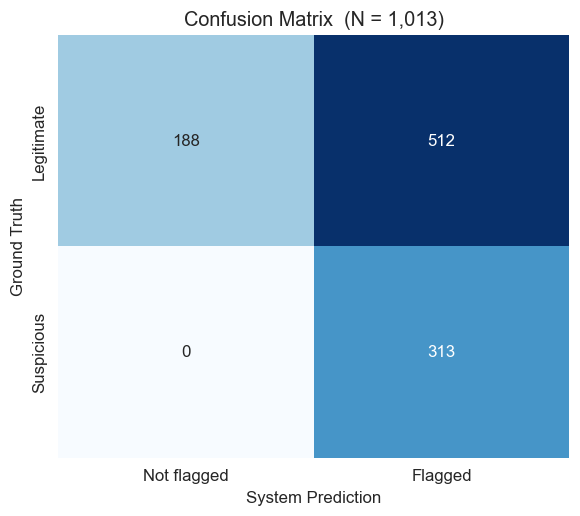

In [8]:
# Plot the confusion matrix as a heatmap for the report
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not flagged', 'Flagged'],
    yticklabels=['Legitimate', 'Suspicious'],
    cbar=False, ax=ax,
)
ax.set_xlabel('System Prediction')
ax.set_ylabel('Ground Truth')
ax.set_title(f'Confusion Matrix  (N = {len(df):,})')
plt.savefig(FIG_DIR / 'confusion_matrix.png')
plt.show()

## 3. Per-pattern recall

How well do the rules catch each AML pattern that the generator produces? This is more diagnostic than a single F1 — it tells you which patterns are well-covered and which are missed.

In [9]:
suspicious = df[df['is_suspicious_truth']].copy()

by_pattern = (
    suspicious
    .groupby('aml_pattern_truth')
    .agg(total=('was_flagged', 'size'),
        caught=('was_flagged', 'sum'))
    .assign(recall=lambda d: d['caught'] / d['total'])
    .sort_values('recall', ascending=False)
)
by_pattern

,total,caught,recall
aml_pattern_truth,,,
HIGH_VELOCITY,85,85,1.0
IMPOSSIBLE_TRAVEL,28,28,1.0
LARGE_RAPID,14,14,1.0
LAYERING,59,59,1.0
ROUND_TRIP,28,28,1.0
SHELL_COMPANY,14,14,1.0
STRUCTURING,71,71,1.0
TRADE_BASED,14,14,1.0


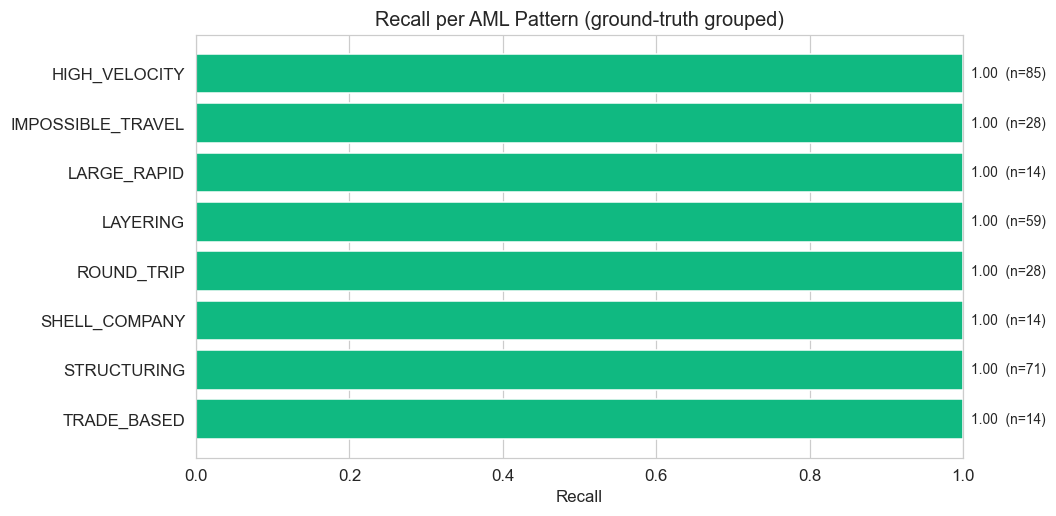

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#10b981' if v >= 0.9 else '#f59e0b' if v >= 0.7 else '#ef4444'
        for v in by_pattern['recall']]
ax.barh(by_pattern.index, by_pattern['recall'], color=colors)
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel('Recall')
ax.set_title('Recall per AML Pattern (ground-truth grouped)')
for i, (recall, total) in enumerate(zip(by_pattern['recall'], by_pattern['total'])):
    ax.text(recall + 0.01, i, f'{recall:.2f}  (n={total})', va='center', fontsize=9)
plt.savefig(FIG_DIR / 'per_pattern_recall.png')
plt.show()

## 4. Per-rule precision

Each transaction can trigger multiple rules. To compute precision *per rule*, we explode `fired_rules` so each (transaction, rule) pair becomes a row, then ask: when this rule fires, what fraction of the time is the underlying transaction actually suspicious?

In [11]:
exploded = (
    df[df['was_flagged']][['transaction_id', 'is_suspicious_truth', 'fired_rules']]
    .explode('fired_rules')
    .rename(columns={'fired_rules': 'rule'})
)

by_rule = (
    exploded
    .groupby('rule')
    .agg(firings=('is_suspicious_truth', 'size'),
         true_positives=('is_suspicious_truth', 'sum'))
    .assign(precision=lambda d: d['true_positives'] / d['firings'])
    .sort_values('precision', ascending=False)
)
by_rule

,firings,true_positives,precision
rule,,,
IMPOSSIBLE_TRAVEL,28,28,1.000000
HIGH_VELOCITY,85,85,1.000000
LARGE_RAPID,14,14,1.000000
SHELL_COMPANY,14,14,1.000000
ROUND_TRIP,28,28,1.000000
LAYERING,59,59,1.000000
TRADE_BASED,14,14,1.000000
STRUCTURING,71,71,1.000000
CROSS_BORDER_HIGH,251,172,0.685259


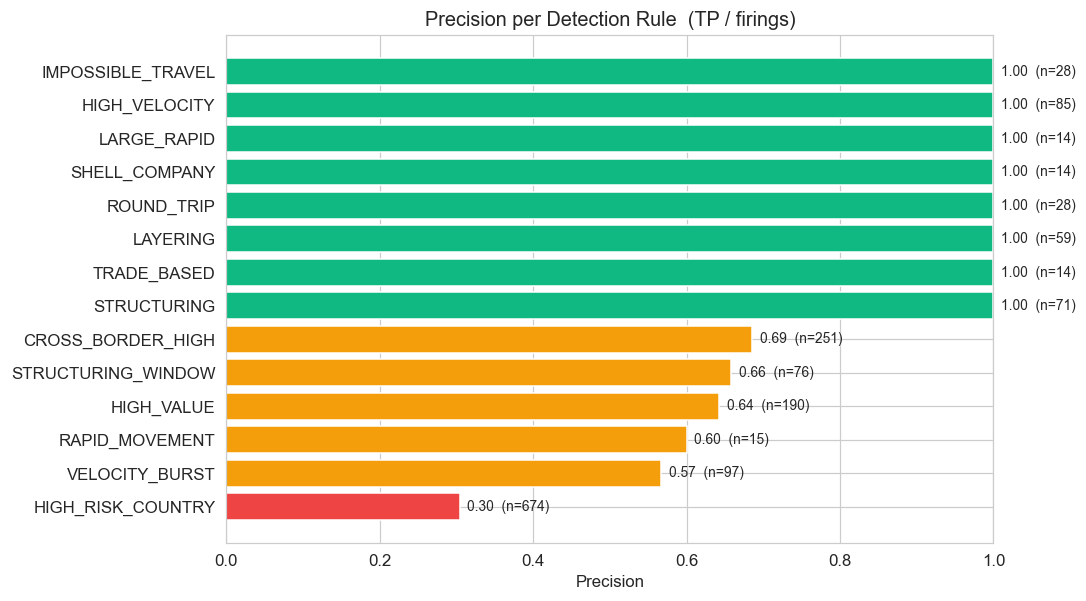

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#10b981' if v >= 0.8 else '#f59e0b' if v >= 0.5 else '#ef4444'
        for v in by_rule['precision']]
ax.barh(by_rule.index, by_rule['precision'], color=colors)
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel('Precision')
ax.set_title('Precision per Detection Rule  (TP / firings)')
for i, (p, n) in enumerate(zip(by_rule['precision'], by_rule['firings'])):
    ax.text(p + 0.01, i, f'{p:.2f}  (n={n})', va='center', fontsize=9)
plt.savefig(FIG_DIR / 'per_rule_precision.png')
plt.show()

## 5. ROC curve and AUC

Treat `max_alert_score` (0..100) as a continuous classifier score. Sweep the decision threshold from 100 down to 0. At each threshold, compute (FPR, TPR). The resulting curve summarises the classifier's behaviour across **all** possible thresholds. The area under it (AUC) is a single number from 0.5 (random) to 1.0 (perfect).

This is the figure your advisor explicitly asked for.

In [13]:
y_score = df['max_alert_score']

fpr_curve, tpr_curve, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr_curve, tpr_curve)
print(f'AUC = {roc_auc:.4f}')

AUC = 0.9546


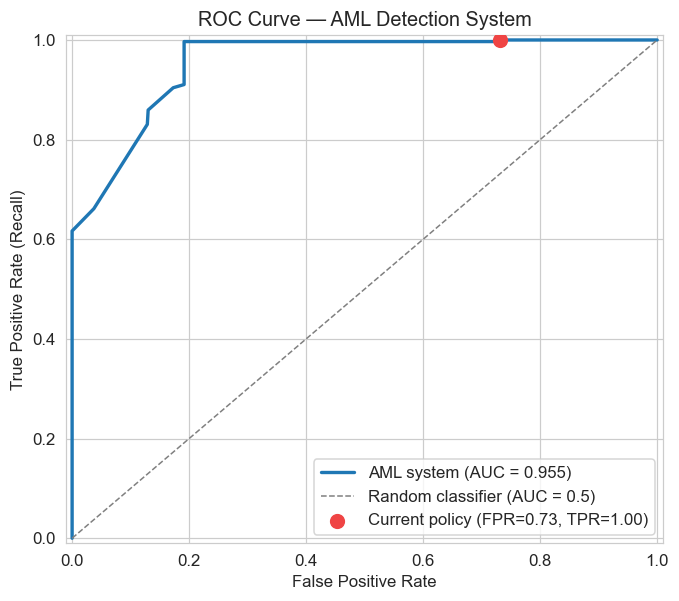

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_curve, tpr_curve,
        color='#1f77b4', lw=2.2,
        label=f'AML system (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random classifier (AUC = 0.5)')

# Mark the operating point of the current any-rule-fires policy
ax.scatter([fpr_val], [recall], color='#ef4444', s=80, zorder=5,
                label=f'Current policy (FPR={fpr_val:.2f}, TPR={recall:.2f})')

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — AML Detection System')
ax.legend(loc='lower right')
plt.savefig(FIG_DIR / 'roc_curve.png')
plt.show()

### Threshold trade-off table

Pick a few threshold values and show what happens to TPR / FPR / F1. This is gold for the discussion section — it lets you say *“lowering the alert_score threshold from 70 to 50 trades 5pp of FPR for 8pp of recall.”*

In [15]:
rows = []
for thr in [0, 30, 50, 60, 70, 80, 90, 100]:
    pred = y_score >= thr
    if pred.sum() == 0:
        rows.append((thr, 0, 0, 0, 0, 0))
        continue
    tp_t = ((pred) & (y_true)).sum()
    fp_t = ((pred) & (~y_true)).sum()
    fn_t = ((~pred) & (y_true)).sum()
    tn_t = ((~pred) & (~y_true)).sum()
    p_t  = tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0
    r_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) else 0
    f1_t = 2*p_t*r_t / (p_t + r_t) if (p_t + r_t) else 0
    rows.append((thr, p_t, r_t, fpr_t, f1_t, int(pred.sum())))

thr_df = pd.DataFrame(rows, columns=['threshold', 'precision', 'recall', 'fpr', 'f1', 'flagged'])
thr_df.round(4)

,threshold,precision,recall,fpr,f1,flagged
0,0,0.3090,1.0000,1.0000,0.4721,1013
1,30,0.3794,1.0000,0.7314,0.5501,825
2,50,0.3794,1.0000,0.7314,0.5501,825
3,60,0.3786,0.9968,0.7314,0.5488,824
4,70,0.6802,0.9105,0.1914,0.7787,419
5,80,0.7472,0.8594,0.1300,0.7994,360
6,90,0.8884,0.6613,0.0371,0.7582,233
7,100,1.0000,0.5016,0.0000,0.6681,157


## 6. Summary block to paste into the report

Run this last cell to print a clean text block ready to drop into Section 10.4 / 11 / abstract.

In [16]:
print('='*62)
print('AML DETECTION SYSTEM — EVALUATION SUMMARY')
print('='*62)
print(f'Total transactions evaluated : {len(df):,}')
print(f'  ground-truth suspicious    : {int(y_true.sum()):,} '
      f'({100*y_true.mean():.2f}%)')
print(f'  ground-truth legitimate    : {int((~y_true).sum()):,} '
      f'({100*(~y_true).mean():.2f}%)')
print()
print('Confusion matrix:')
print(f'  TP = {tp:6d}    FP = {fp:6d}')
print(f'  FN = {fn:6d}    TN = {tn:6d}')
print()
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 score  : {f1:.4f}')
print(f'Accuracy  : {accuracy:.4f}')
print(f'FPR       : {fpr_val:.4f}')
print(f'AUC (ROC) : {roc_auc:.4f}')
print('='*62)

AML DETECTION SYSTEM — EVALUATION SUMMARY
Total transactions evaluated : 1,013
  ground-truth suspicious    : 313 (30.90%)
  ground-truth legitimate    : 700 (69.10%)

Confusion matrix:
  TP =    313    FP =    512
  FN =      0    TN =    188

Precision : 0.3794
Recall    : 1.0000
F1 score  : 0.5501
Accuracy  : 0.4946
FPR       : 0.7314
AUC (ROC) : 0.9546
